#### Simple Hyperparameter Search
Implement hyperparameter search using grid search or random search:
<ol>
    <li>Perform a grid or random search over the following hyperparameters
(small search because it takes a long time):
        <ol>
            <li>
                The base number of filters: 16 or 32 (note that the base number of
filters should be doubled after every maxpool operation)
            </li>
            <li>
                The size of filters: 3x3 or 5x5
            </li>
            <li>
                The number of convolution layer blocks (conv, batchnorm, relu,
maxpool): 3, 4, or 5. Note that you should include maxpool layers after
conv blocks 1 and 3. 
            </li>
            <li>
                Note that there should be 12 models to train in total.
            </li>  
        </ol>
    <li>
        Implement some form of speed-up – e.g. reduce the size of the training  data set by 50% and/or use parallel processing (the parfor loop in matlab or in Optuna using the n_jobs parameter in optimize())
    </li>
    <li>
        Implement some form of model checkpointing to ensure robustness in
case of computer failure, e.g. save each model in the grid search at the end
of training. See hints at the end of this doc for model checkpointing.
    </li>
    <li>
        Produce a table of accuracy results for evaluation purposes, note the best
model and compare to your baseline model.
    </li>
</ol>

In [1]:
import torch
from torch import nn
import torch.nn.functional as F #For activation fns, loss fun etc.,
import torch.optim as optim #Optimization module
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary #To display model architecture
from torch.utils.tensorboard  import SummaryWriter

import torchvision
from torchvision import datasets
from torchvision.transforms import v2 as transforms
from torchvision.ops import Conv2dNormActivation

from torchaudio.transforms import FrequencyMasking, TimeMasking

from dataclasses import dataclass
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sn

import matplotlib.pyplot as plt
import numpy as np
import random
import time
import warnings
import os
from tqdm import tqdm

import pandas as pd
%matplotlib inline
warnings.filterwarnings("ignore")

In [2]:
import optuna
from torch.utils.data import Subset
import os

In [3]:
def set_seeds():
    """
    Sets a fixed seed value for reproducibility across multiple libraries (random, NumPy)
    This ensures that model training and results remain consistent across multiple runs.
    """
    SEED_VALUE = 42

    random.seed(SEED_VALUE)

    np.random.seed(SEED_VALUE)

    torch.manual_seed(SEED_VALUE)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED_VALUE) #Single GPU
        torch.cuda.manual_seed_all(SEED_VALUE) #Multiple GPU

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True

set_seeds()

#### Training Configuration Parameters

In [4]:
@dataclass(frozen=True)
class TrainingConfig:
    """Configuration for training"""
    batch_size: int = 64
    num_epochs: int = 40
    learning_rate: float = 1e-4

    log_interval: int = 1
    test_interval: int = 1
    data_root: int = "./speechImageData/speechImageData - Copy/"
    num_workers: int = 4 #number of thread involving in loading image
    deviec:str = 'cpu'

train_config = TrainingConfig()
DEVICE = torch.device("cuda") if torch.cuda.is_available() else "cpu"
print(f"Available device {DEVICE}")

Available device cpu


#### Load Custom data available in Pytorch

In [5]:
train_root = os.path.join(train_config.data_root, "TrainData")
val_root = os.path.join(train_config.data_root, "ValData")

#### Data Preprocessing

In [6]:
mean = [0.4193]  #mean and std of this speech data
std = [0.3362]

img_size = (98, 50)

preprocess = transforms.Compose([
    transforms.Resize(img_size, antialias=True),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

In [7]:
common_transform = transforms.Compose([
    preprocess,
    transforms.Normalize(mean, std)
])

train_transforms = transforms.Compose([
    preprocess,
    transforms.RandomApply([
        TimeMasking(time_mask_param=10),
        FrequencyMasking(freq_mask_param=5)
    ],p=0.9),
    transforms.Normalize(mean,std)
])

#### Data Loader Preparation

In [8]:
train_data = datasets.ImageFolder(root= train_root, transform=train_transforms)
val_data = datasets.ImageFolder(root= val_root, transform=common_transform)

train_data.classes

['background',
 'down',
 'go',
 'left',
 'no',
 'off',
 'on',
 'right',
 'stop',
 'unknown',
 'up',
 'yes']

In [9]:
#Load only 50% of the train data
train_subset = Subset(train_data, range(len(train_data)//2))

train_loader = DataLoader(
    train_subset,
    shuffle=True,
    batch_size= train_config.batch_size,
    num_workers = train_config.num_workers
)

val_loader = DataLoader(
    val_data,
    shuffle=False,
    batch_size= train_config.batch_size,
    num_workers= train_config.num_workers 
)

In [9]:
#Load only 100% of the train data
train_loader = DataLoader(
    train_data,
    shuffle=True,
    batch_size= train_config.batch_size,
    num_workers = train_config.num_workers
)

val_loader = DataLoader(
    val_data,
    shuffle=False,
    batch_size= train_config.batch_size,
    num_workers= train_config.num_workers 
)

#### Display Images from the Dataset

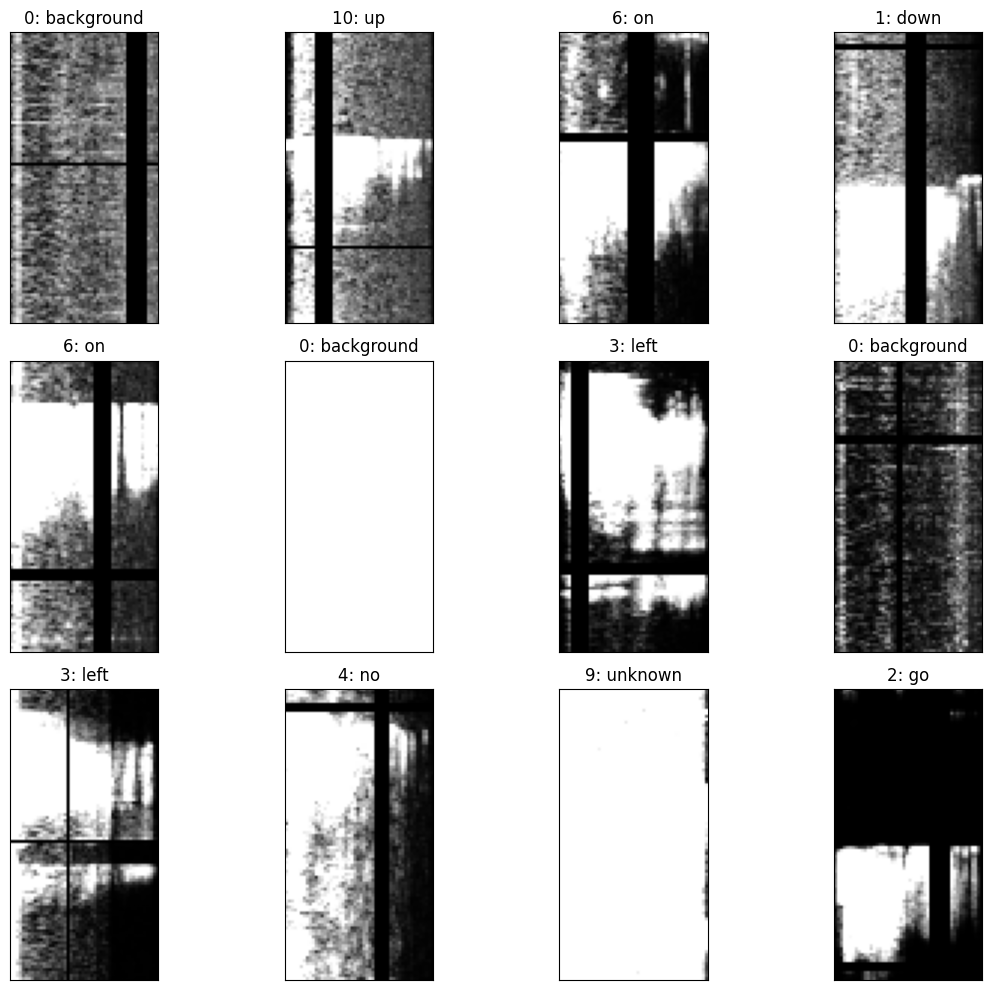

In [10]:
def visualize_images(trainloader, number_of_images=12):
    fig = plt.figure(figsize=(12,10))

    images, labels = next(iter(train_loader))

    num_rows = 3
    num_col = int(np.ceil(number_of_images/num_rows))

    for idx in range(min(number_of_images, len(images))):
        image, label = images[idx], labels[idx]

        #Create a subplot 
        ax = fig.add_subplot(num_rows, num_col, idx+1, xticks=[], yticks=[])

        image = image.squeeze()
        image = (image - image.min())/ (image.max() - image.min())
       
        ax.imshow(image, cmap='gray')

        ax.set_title(f"{label.item()}: {train_data.classes[label.item()]}")

    fig.tight_layout()

    plt.savefig("time_frequency_masking.pdf", dpi=600, bbox_inches="tight")
    plt.show()
visualize_images(train_loader)

#### CNN Model Implementation

In [68]:
class Model(nn.Module):
    def __init__(self, trial):
        super().__init__()

        self.base_num_filters = trial.suggest_categorical("base_num_filter", [16,32]) #for hp tuning
        self.filter_size = trial.suggest_categorical("filter_size", [3,5]) #for hp tuning
        self.num_layer = trial.suggest_categorical("num_layer", [3,4,5]) #for hp tunning

        layers = []

        width, height, c = 98, 50, 1

        filter_mul = 1

        for i in range(self.num_layer):
            layers.append(nn.Conv2d(in_channels=c, out_channels=self.base_num_filters * filter_mul, kernel_size=self.filter_size, padding="same"))
            layers.append(nn.BatchNorm2d(self.base_num_filters * filter_mul))
            layers.append(nn.ReLU())

            c = self.base_num_filters * filter_mul
            if ((i+1) % 2) == 0:
                layers.append(nn.MaxPool2d(kernel_size=(4,2), stride=(4,2)))
                filter_mul *= 2
                width = torch.floor_divide(width - 4, 4) + 1
                height = torch.floor_divide(height - 2, 2) + 1
                
        #-------Flatten------------
        layers.append(nn.Flatten())
        #------Classification------    
        layers.append(nn.Linear(in_features=width*height*c, out_features=256))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(p=0.4))
        layers.append(nn.Linear(in_features=256, out_features=12))
        
        self._model = nn.Sequential(*layers)
        
    def forward(self, x):
        return self._model(x)

In [15]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.base_num_filters = 32
        self.filter_size = 5
        self.num_layer = 4

        layers = []

        width, height, c = 98, 50, 1

        filter_mul = 1

        for i in range(self.num_layer):
            layers.append(nn.Conv2d(in_channels=c, out_channels=self.base_num_filters * filter_mul, kernel_size=self.filter_size, padding="same"))
            layers.append(nn.BatchNorm2d(self.base_num_filters * filter_mul))
            layers.append(nn.ReLU())

            c = self.base_num_filters * filter_mul
            if ((i+1) % 2) == 0:
                layers.append(nn.MaxPool2d(kernel_size=(4,2), stride=(4,2)))
                filter_mul *= 2
                width = torch.floor_divide(width - 4, 4) + 1
                height = torch.floor_divide(height - 2, 2) + 1
                
        #-------Flatten------------
        layers.append(nn.Flatten())
        #------Classification------    
        layers.append(nn.Linear(in_features=width*height*c, out_features=256))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(p=0.4))
        layers.append(nn.Linear(in_features=256, out_features=12))
        
        self._model = nn.Sequential(*layers)
        
    def forward(self, x):
        return self._model(x)

#### Model Training and Evaluation

In [12]:
def train(model, train_loader, optimizer, DEVICE):

    #set model to training mode
    model.train()

    #Move model to specified device
    model.to(DEVICE)

    running_loss = 0

    correct_prediction = 0

    total_samples = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        #Reset to zero
        optimizer.zero_grad()

        #Forward pass
        outputs = model(images)

        loss = F.cross_entropy(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, dim=1)

        total_samples += labels.size(0)

        correct_prediction += (predicted == labels).sum().item()

    avg_loss = running_loss / len(train_loader)

    accuracy = 100 * correct_prediction/ total_samples

    return avg_loss, accuracy

In [13]:
def validation(model, val_loader, DEVICE):
    model.eval()
    model.to(DEVICE)

    running_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)

            loss = F.cross_entropy(outputs, labels)

            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, dim=1)
            
            total_samples += labels.size(0)
            
            correct_predictions += (predicted == labels).sum().item()
            
        avg_loss = running_loss / len(val_loader)

        accuracy = 100 * correct_predictions/ total_samples

    return avg_loss, accuracy 

In [108]:
def objective(trial):
    
    model = Model(trial)
    
    optimizer = torch.optim.Adam(model.parameters(), lr= train_config.learning_rate, weight_decay=.1)

    logdir = "runs/80epoch-3.3M_param_dropout"

    writer = SummaryWriter(logdir)

    dummy_input = (1,1,98,50)

    print(summary(model, dummy_input, row_settings=["var_names"], device='cpu'))
    
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_accuracy = 0.0
    best_weights = None

    print(trial.params)
    
    model_name = f"Model_BNF{trial.params['base_num_filter']}_FS{trial.params['filter_size']}_NL{trial.params['num_layer']}"

     # Resume if checkpoint exists
    start_epoch = 0
    if os.path.exists(f'Checkpoints/{model_name}.pt'):
        checkpoint = torch.load(f'Checkpoints/{model_name}.pt')
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch']
    
    for epoch in range(start_epoch, train_config.num_epochs):
        if epoch % 5 == 0:
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
            }
            torch.save(checkpoint, f'Checkpoint/{model_name}.pt')
        train_loss, train_accuracy = train(model,train_loader, optimizer, DEVICE)
        val_loss, val_accuracy = validation(model, val_loader, DEVICE)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1} - Train loss: {train_loss} Train accuracy: {train_accuracy} %%% Val loss: {val_loss} Val accuracy: {val_accuracy}")

        trial.report(val_accuracy, epoch)
        
        writer.add_scalar('Loss/train', train_loss)
        writer.add_scalar('Loss/val', val_loss)
        writer.add_scalar('Accuracy/train', train_accuracy)
        writer.add_scalar('Accuracy/val', val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_weights = model.state_dict()
            print("Saving the model... ")
            torch.save(best_weights, "best.pt")
            

    return val_accuracies[-1]

In [109]:
# Create study
search_space = {
    "filter_size": [3, 5],
    "base_num_filter": [16, 32],
    "num_layer": [3, 4, 5]
}


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.GridSampler(search_space))

# Optimize
study.optimize(objective, n_trials=12)


[I 2026-03-18 16:43:30,083] A new study created in memory with name: no-name-abb4e151-860a-4772-a26c-d0f3d144b4f5


Layer (type (var_name))                  Output Shape              Param #
Model (Model)                            [1, 12]                   --
├─Sequential (_model)                    [1, 12]                   --
│    └─Conv2d (0)                        [1, 32, 98, 50]           320
│    └─BatchNorm2d (1)                   [1, 32, 98, 50]           64
│    └─ReLU (2)                          [1, 32, 98, 50]           --
│    └─Conv2d (3)                        [1, 32, 98, 50]           9,248
│    └─BatchNorm2d (4)                   [1, 32, 98, 50]           64
│    └─ReLU (5)                          [1, 32, 98, 50]           --
│    └─MaxPool2d (6)                     [1, 32, 24, 25]           --
│    └─Conv2d (7)                        [1, 64, 24, 25]           18,496
│    └─BatchNorm2d (8)                   [1, 64, 24, 25]           128
│    └─ReLU (9)                          [1, 64, 24, 25]           --
│    └─Flatten (10)                      [1, 38400]                --
│    └

Validation: 100%|███████████████████████████████| 19/19 [00:02<00:00,  6.36it/s]


Epoch 1 - Train loss: 1.5835222378373146 Train accuracy: 41.4 %%% Val loss: 3.2859645517248857 Val accuracy: 10.67463706233988
Saving the model... 


Validation: 100%|███████████████████████████████| 19/19 [00:02<00:00,  6.44it/s]


...

Epoch 38 - Train loss: 0.15855506621301174 Train accuracy: 96.9 %%% Val loss: 3.789689083436602 Val accuracy: 36.54995730145175
Saving the model... 


Validation: 100%|███████████████████████████████| 19/19 [00:02<00:00,  8.91it/s]


Epoch 39 - Train loss: 0.16156369680538774 Train accuracy: 96.4 %%% Val loss: 4.46626361988877 Val accuracy: 33.90264730999146


Validation: 100%|███████████████████████████████| 19/19 [00:02<00:00,  9.35it/s]
[I 2026-03-18 18:06:02,331] Trial 11 finished with value: 35.61058923996584 and parameters: {'base_num_filter': 16, 'filter_size': 5, 'num_layer': 5}. Best is trial 3 with value: 37.31853116994022.


Epoch 40 - Train loss: 0.14807046623900533 Train accuracy: 97.1 %%% Val loss: 3.5551365870786342 Val accuracy: 35.61058923996584


In [112]:
study.best_params

{'base_num_filter': 32, 'filter_size': 5, 'num_layer': 4}

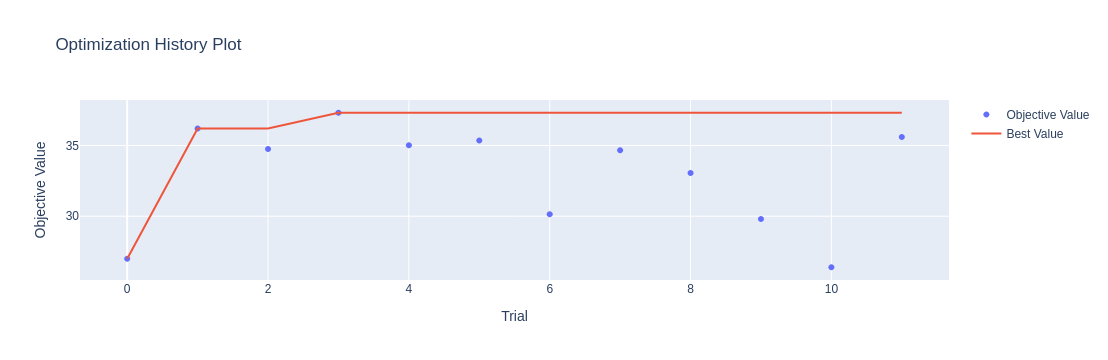

In [117]:
optuna.visualization.plot_optimization_history(study)

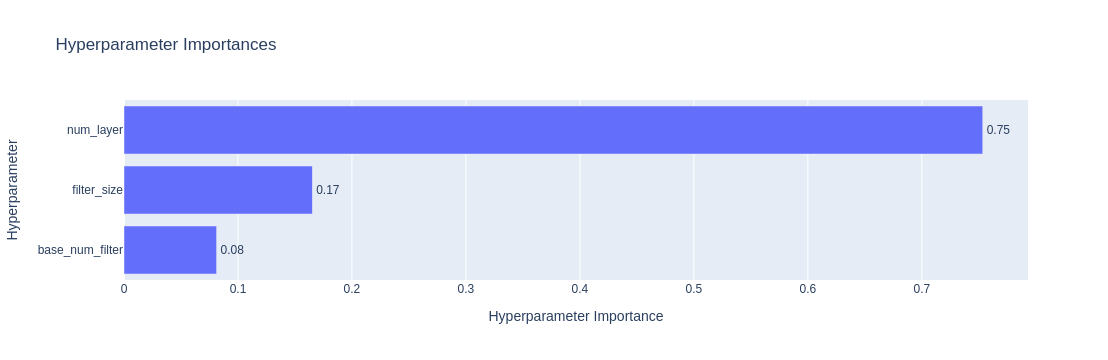

In [114]:
optuna.visualization.plot_param_importances(study)

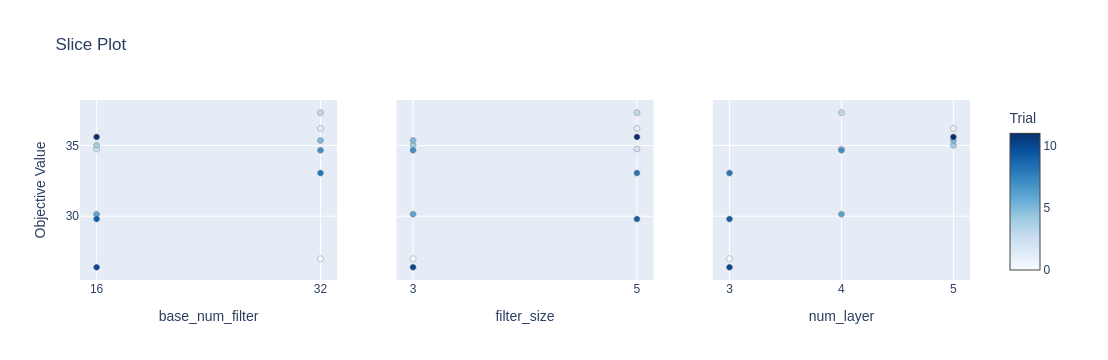

In [115]:
optuna.visualization.plot_slice(study)

In [30]:
train_loader.batch_size

64

In [16]:
model = Model()

optimizer = torch.optim.Adam(model.parameters(), lr= train_config.learning_rate, weight_decay=.1)

logdir = "runs/80epoch-3.3M_param_dropout"

writer = SummaryWriter(logdir)

dummy_input = (1,1,98,50)

print(summary(model, dummy_input, row_settings=["var_names"], device='cpu'))

Layer (type (var_name))                  Output Shape              Param #
Model (Model)                            [1, 12]                   --
├─Sequential (_model)                    [1, 12]                   --
│    └─Conv2d (0)                        [1, 32, 98, 50]           832
│    └─BatchNorm2d (1)                   [1, 32, 98, 50]           64
│    └─ReLU (2)                          [1, 32, 98, 50]           --
│    └─Conv2d (3)                        [1, 32, 98, 50]           25,632
│    └─BatchNorm2d (4)                   [1, 32, 98, 50]           64
│    └─ReLU (5)                          [1, 32, 98, 50]           --
│    └─MaxPool2d (6)                     [1, 32, 24, 25]           --
│    └─Conv2d (7)                        [1, 64, 24, 25]           51,264
│    └─BatchNorm2d (8)                   [1, 64, 24, 25]           128
│    └─ReLU (9)                          [1, 64, 24, 25]           --
│    └─Conv2d (10)                       [1, 64, 24, 25]           102,464


In [17]:
def main(model, trainloader, val_loader, DEVICE='cpu'):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_accuracy = 0.0
    best_weights = None

    for epoch in range(train_config.num_epochs):
        train_loss, train_accuracy = train(model,trainloader, optimizer, DEVICE)
        val_loss, val_accuracy = validation(model, val_loader, DEVICE)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1} - Train loss: {train_loss} Train accuracy: {train_accuracy} %%% Val loss: {val_loss} Val accuracy: {val_accuracy}")

        writer.add_scalar('Loss/train', train_loss)
        writer.add_scalar('Loss/val', val_loss)
        writer.add_scalar('Accuracy/train', train_accuracy)
        writer.add_scalar('Accuracy/val', val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_weights = model.state_dict()
            print("Saving the model... ")
            torch.save(best_weights, "best_best_task_2.pt")
            

    return train_losses, val_losses, train_accuracies, val_accuracies

In [18]:
train_losses, val_losses, train_accuracies, val_accuracies = main(model, train_loader, val_loader, 'cpu')

Validation: 100%|███████████████████████████████| 19/19 [00:05<00:00,  3.48it/s]


Epoch 1 - Train loss: 2.3199635297060013 Train accuracy: 20.839580209895054 %%% Val loss: 2.4297104697478447 Val accuracy: 14.005123825789923
Saving the model... 


Validation: 100%|███████████████████████████████| 19/19 [00:05<00:00,  3.25it/s]


Epoch 2 - Train loss: 2.05916478484869 Train accuracy: 30.284857571214392 %%% Val loss: 2.1937391412885567 Val accuracy: 27.754056362083688
Saving the model... 


Validation: 100%|███████████████████████████████| 19/19 [00:06<00:00,  2.75it/s]


...

Epoch 38 - Train loss: 0.37421563267707825 Train accuracy: 91.2543728135932 %%% Val loss: 0.8670128168244111 Val accuracy: 73.5269000853971
Saving the model... 


Validation: 100%|███████████████████████████████| 19/19 [00:05<00:00,  3.50it/s]


Epoch 39 - Train loss: 0.37028697971254587 Train accuracy: 91.20439780109945 %%% Val loss: 0.9241149260809547 Val accuracy: 71.22117847993168


Validation: 100%|███████████████████████████████| 19/19 [00:06<00:00,  2.97it/s]

Epoch 40 - Train loss: 0.3560342970304191 Train accuracy: 92.40379810094953 %%% Val loss: 0.8770135724426884 Val accuracy: 70.28181041844577


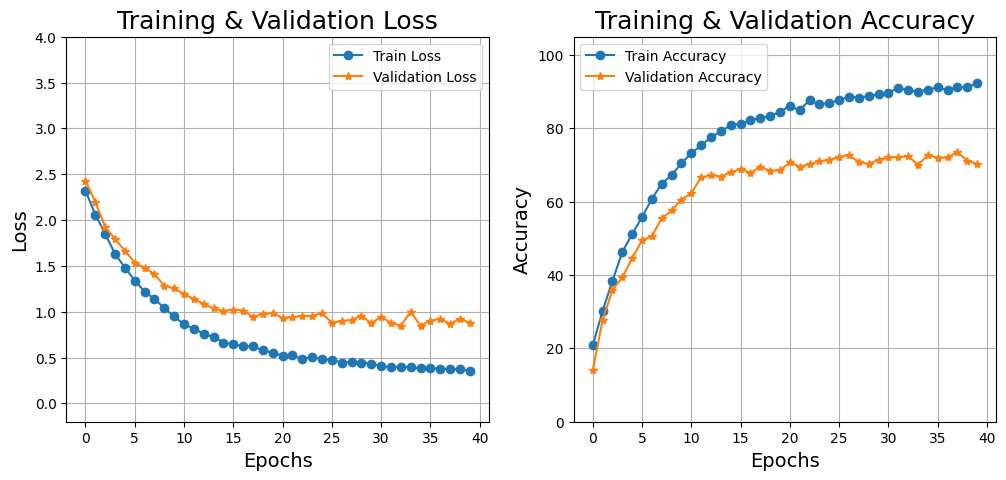

In [19]:
FONT_SIZE = 14
TITLE_SIZE = 18
X_LABEL_SIZE = 14
Y_LABEL_SIZE = 14
LEGEND_SIZE = 10

PLOT_FILE = "task_2_with_best_parameter.pdf"

plt.figure(figsize=[12,5])

plt.subplot(1,2,1)
plt.plot(range(0,len(train_losses)), train_losses, label="Train Loss", marker='o')
plt.plot(range(0,len(train_losses)), val_losses, label="Validation Loss", marker='*')

plt.ylim([-0.2,4])
plt.xlabel("Epochs", fontsize=X_LABEL_SIZE)
plt.ylabel("Loss", fontsize=Y_LABEL_SIZE)
plt.title("Training & Validation Loss", fontsize=TITLE_SIZE)
plt.grid()

plt.legend()

plt.subplot(1,2,2)
plt.plot(range(0,len(train_accuracies)), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(0,len(val_accuracies)), val_accuracies, label="Validation Accuracy", marker='*')

plt.ylim([0,105])
plt.xlabel("Epochs", fontsize=X_LABEL_SIZE)
plt.ylabel("Accuracy", fontsize=Y_LABEL_SIZE)
plt.title("Training & Validation Accuracy", fontsize=TITLE_SIZE)

plt.legend()

plt.grid()

plt.savefig(PLOT_FILE, dpi=600, bbox_inches="tight")